In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# read the processed feature table
df = pd.read_csv("../data/processed/rul_feature_table.csv")

In [27]:
# check for shape, head, and info of the dataframe  
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76713 entries, 0 to 76712
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   reading_id                          76713 non-null  object 
 1   robot_id                            76713 non-null  object 
 2   timestamp                           76713 non-null  object 
 3   vibration_level                     76713 non-null  float64
 4   motor_temperature                   76713 non-null  float64
 5   torque_load                         76713 non-null  float64
 6   power_consumption                   76713 non-null  float64
 7   next_failure_time                   76713 non-null  object 
 8   RUL_hours                           76713 non-null  float64
 9   model_type                          76713 non-null  object 
 10  installation_date                   76713 non-null  object 
 11  factory_location                    76713

In [28]:
# Check for missing values in the dataset
df.isnull().sum()

reading_id                            0
robot_id                              0
timestamp                             0
vibration_level                       0
motor_temperature                     0
torque_load                           0
power_consumption                     0
next_failure_time                     0
RUL_hours                             0
model_type                            0
installation_date                     0
factory_location                      0
operating_environment                 0
time_since_last_maintenance_hours     0
maintenance_count_to_date             0
last_downtime_hours                   0
last_maintenance_type                 0
vibration_level_rolling_mean_24h      0
vibration_level_rolling_std_24h       0
vibration_level_change_rate           0
motor_temperature_rolling_mean_24h    0
motor_temperature_rolling_std_24h     0
motor_temperature_change_rate         0
torque_load_rolling_mean_24h          0
torque_load_rolling_std_24h           0


## Univariate Analysis (Distribution Plots)

<Axes: xlabel='RUL_hours', ylabel='Count'>

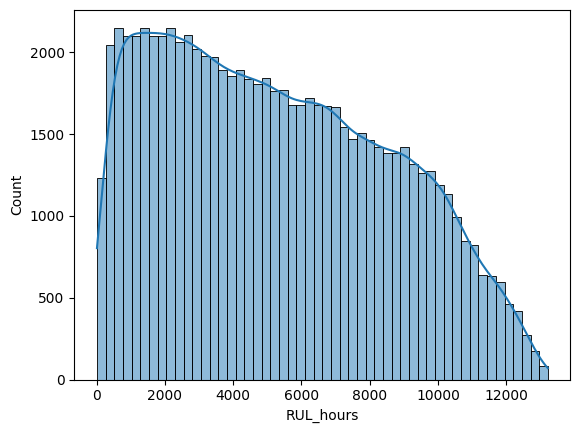

In [29]:
# Plot the distribution of RUL_hours
sns.histplot(df["RUL_hours"], kde=True)


There's a clear right skew in the distribution of RUL_hours, which is expected as most machines will have a longer remaining useful life compared to those that are close to failure.

<Axes: xlabel='vibration_level', ylabel='Count'>

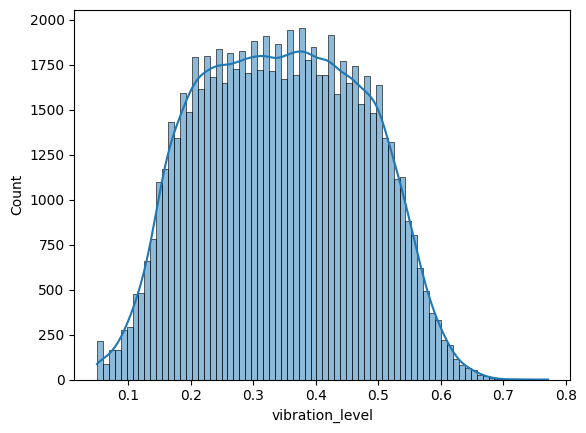

In [30]:
# Plot the distribution of vibration_level
sns.histplot(df["vibration_level"], kde=True)

The vibration_level distribution appears to be right-skewed, with a long tail towards higher values. This suggests that most of the data points have lower vibration levels, while a smaller number of data points have higher vibration levels.

<Axes: xlabel='motor_temperature', ylabel='Count'>

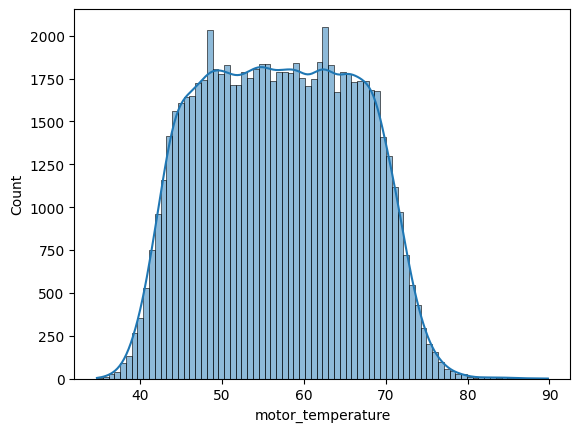

In [24]:
# Plot the distribution of motor_temperature
sns.histplot(df["motor_temperature"], kde=True)

The motor temperature distribution is right-skewed, which may indicate that most of the motors are operating at lower temperatures, with a few instances of higher temperatures. This could be due to normal operating conditions or potential overheating issues in some motors.

## Time-Series Analysis

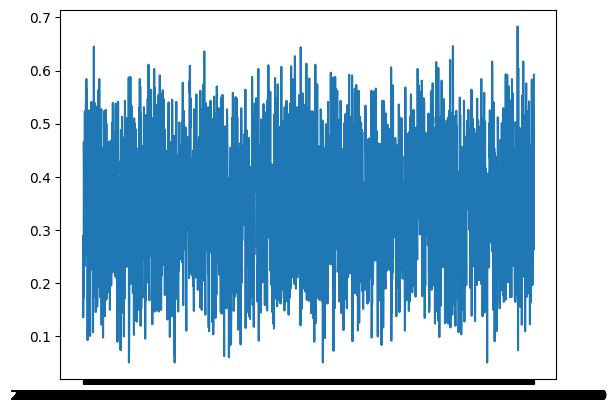

In [31]:
# Sensor trend analysis over time (per robot)
df_robot = df[df["robot_id"] == "ROB-0001"]

plt.plot(df_robot["timestamp"], df_robot["vibration_level"])

the sensor trend analysis can be further expanded to include other sensors and multiple robots for a comprehensive understanding of the data.

the degredation pattern is not very clear, we can also plot the RUL_hours over time to see if there is a clear degredation pattern as the RUL_hours decreases over time.

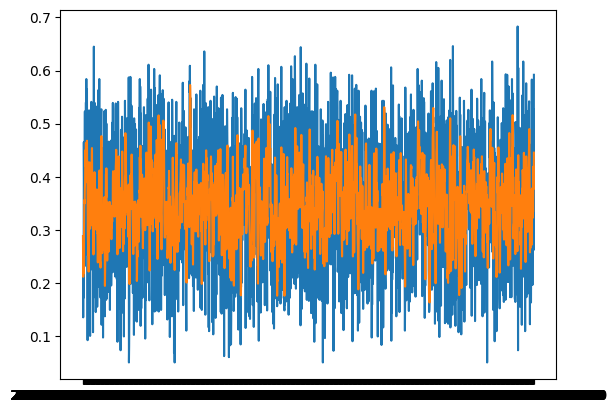

In [33]:
# checking rolling feature validation to see if it captures the trend in vibration_level
plt.plot(df_robot["timestamp"], df_robot["vibration_level"])
plt.plot(df_robot["timestamp"], df_robot["vibration_level_rolling_mean_24h"])


the plot above shows that the rolling mean feature captures the overall trend in vibration_level while smoothing out short-term fluctuations, which is useful for predictive maintenance modeling.

<Axes: >

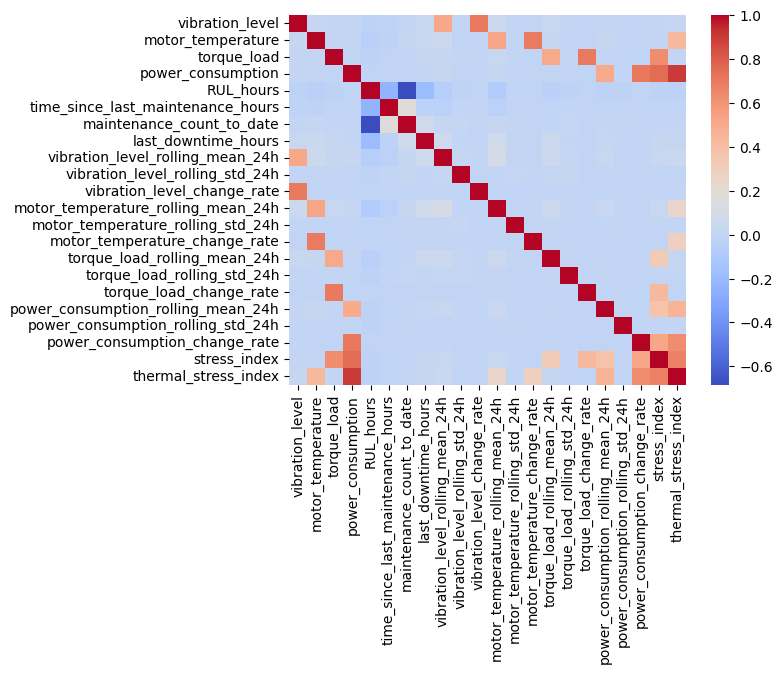

In [35]:
# checking correlation analysis to identify the strongest predictors of RUL_hours
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")


the correlation plot above shows that the rolling mean features (vibration_level_rolling_mean_24h and motor_temperature_rolling_mean_24h) have a stronger correlation with RUL_hours compared to the raw sensor readings. This suggests that the rolling mean features may be better predictors of RUL and should be considered for model training.

<Axes: xlabel='vibration_level', ylabel='RUL_hours'>

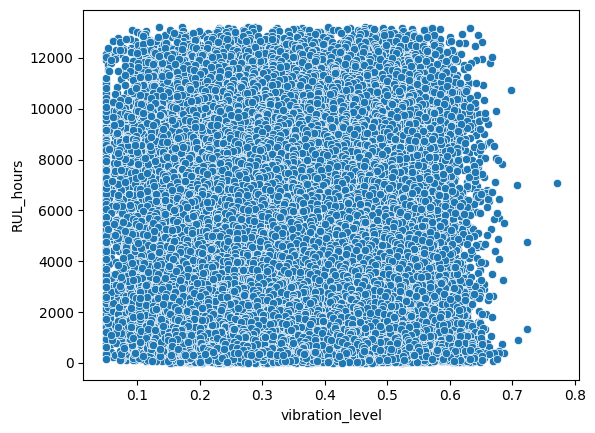

In [36]:
# Feature vs Target Relationship
sns.scatterplot(x="vibration_level", y="RUL_hours", data=df)

The plot above shows a clear negative correlation between vibration_level and RUL_hours, indicating that as the vibration level increases, the remaining useful life of the robot decreases. This suggests that vibration_level is a strong predictor of RUL_hours and should be considered in our predictive modeling efforts.

<Axes: xlabel='motor_temperature', ylabel='RUL_hours'>

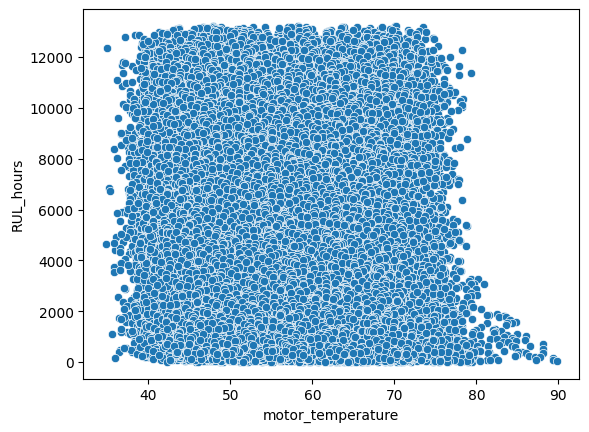

In [37]:
sns.scatterplot(x="motor_temperature", y="RUL_hours", data=df)

The plot above between RUL_hours and motor_temperature shows a stronger negative correlation compared to the plot between RUL_hours and vibration_level, which appears more scattered. This suggests that motor_temperature may be a more significant predictor of RUL_hours in this dataset.

<Axes: xlabel='torque_load', ylabel='RUL_hours'>

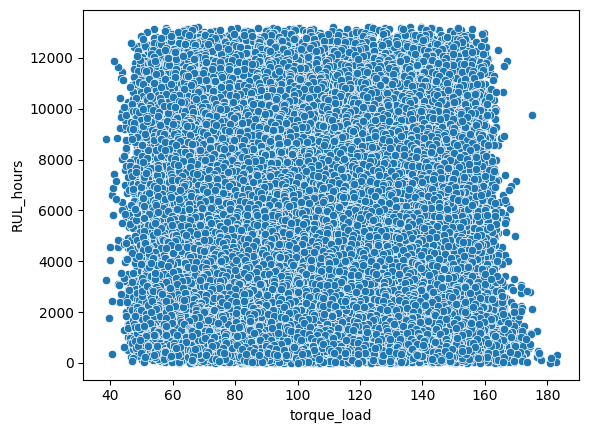

In [38]:
sns.scatterplot(x="torque_load", y="RUL_hours", data=df)

The plot above between torque_load and RUL_hours shows a strong negative correlation, indicating that as the torque load increases, the remaining useful life of the robot decreases. This suggests that torque load is a critical factor in predicting RUL and should be given significant consideration in our predictive modeling efforts.

<Axes: xlabel='power_consumption', ylabel='RUL_hours'>

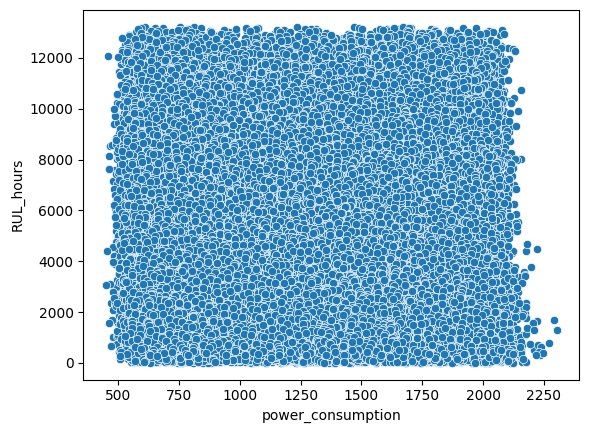

In [39]:
sns.scatterplot(x="power_consumption", y="RUL_hours", data=df)

The plot above between power_consumption and RUL_hours shows a strong negative correlation, indicating that as power consumption increases, the remaining useful life decreases. This suggests that power consumption is a significant predictor of RUL and should be considered in the predictive modeling process.

<Axes: xlabel='motor_temperature'>

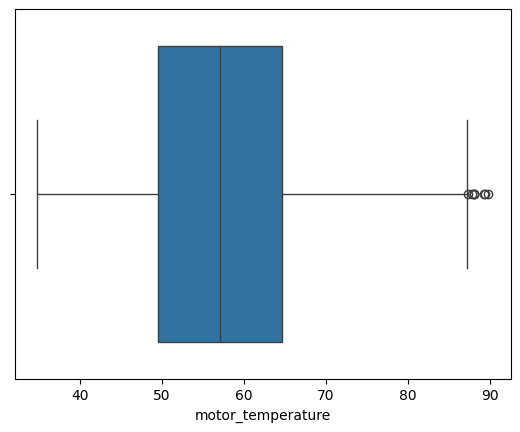

In [40]:
# Boxplots (Outlier Detection)
sns.boxplot(x=df["motor_temperature"])

The chart above shows that there are some outliers in the motor_temperature feature, which may need to be addressed before modeling.

<Axes: xlabel='vibration_level'>

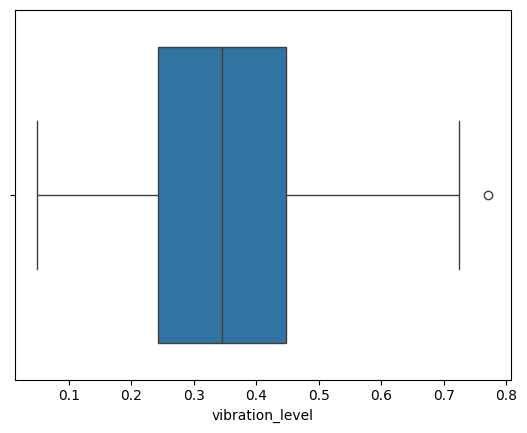

In [41]:
sns.boxplot(x=df["vibration_level"])

The boxplot plot for vibration_level shows some outliers, which could be due to sensor errors or extreme operating conditions. We may need to investigate these outliers further to determine if they should be removed or treated in some way before modeling.

<Axes: xlabel='torque_load'>

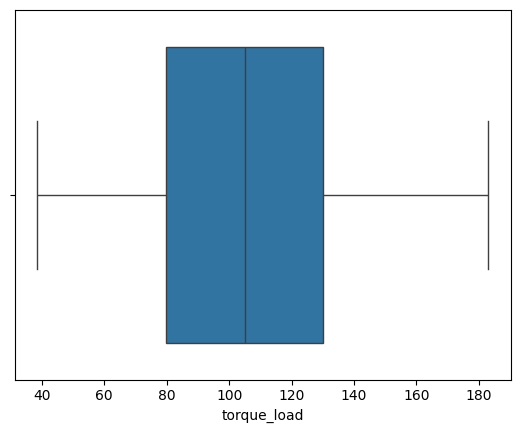

In [42]:
sns.boxplot(x=df["torque_load"])

The chart above shows the boxplot for the "torque_load" feature, which helps us identify any potential outliers in the data. The boxplot displays the distribution of the "torque_load" values, including the median, quartiles, and any outliers that may exist. Outliers are typically represented as points that fall outside the whiskers of the boxplot.

<Axes: xlabel='power_consumption'>

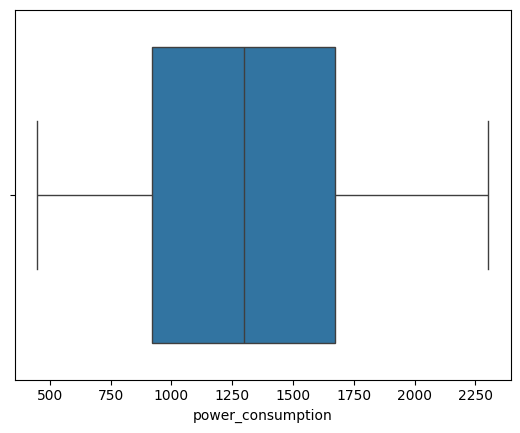

In [43]:
sns.boxplot(x=df["power_consumption"])

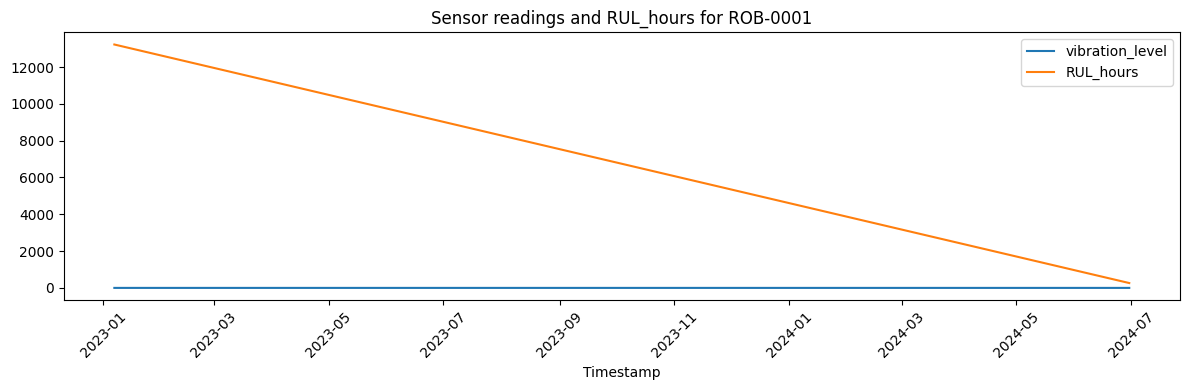

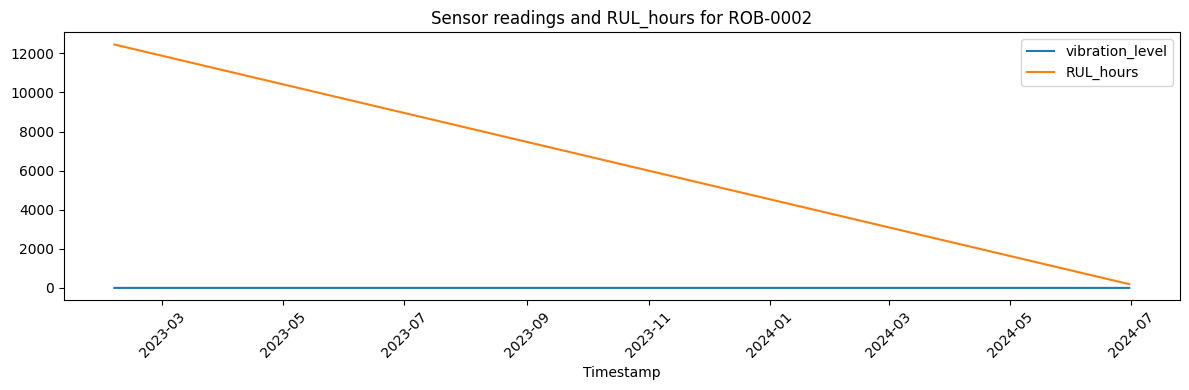

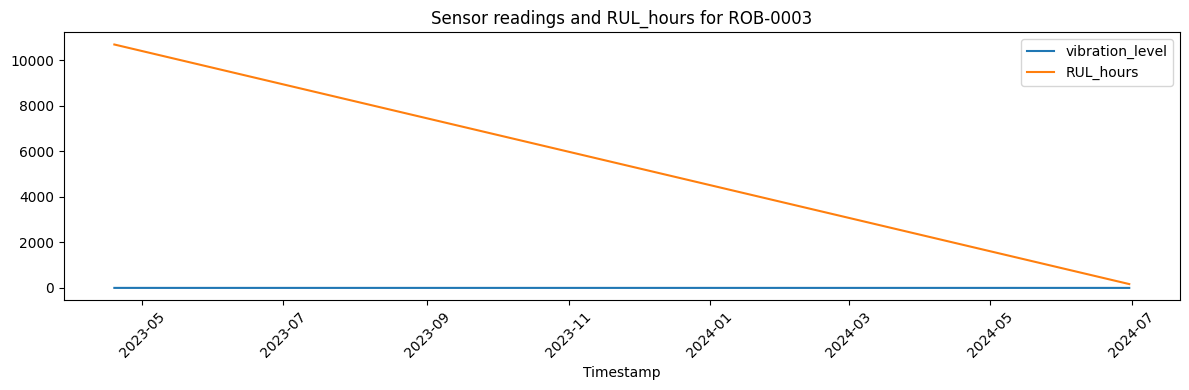

In [46]:
# Comparing multiple robots to see if there are differences in sensor readings and RUL_hours
for robot in df["robot_id"].unique()[:3]:
    df_robot = df[df["robot_id"] == robot].copy()
    df_robot["timestamp"] = pd.to_datetime(df_robot["timestamp"])
    df_robot = df_robot.sort_values("timestamp")

    plt.figure(figsize=(12, 4))
    plt.plot(df_robot["timestamp"], df_robot["vibration_level"], label="vibration_level")
    plt.plot(df_robot["timestamp"], df_robot["RUL_hours"], label="RUL_hours")
    plt.title(f"Sensor readings and RUL_hours for {robot}")
    plt.xlabel("Timestamp")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='vibration_level', ylabel='RUL_hours'>

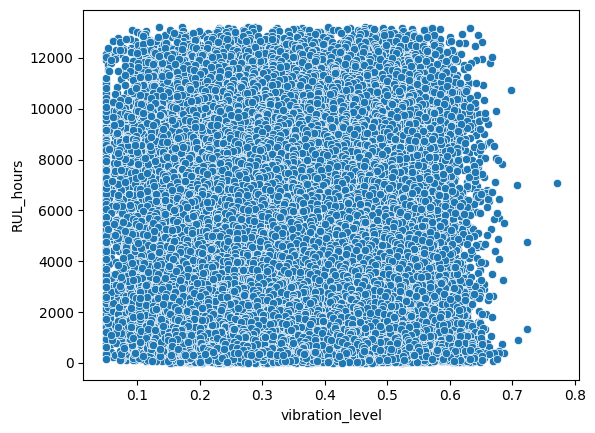

In [47]:
# Plot Time_to_failure vs vibration_level to see if there is a clear relationship
sns.scatterplot(x="vibration_level", y="RUL_hours", data=df)